# [INSTRUCTOR ANSWER KEY] In-Class Lab 1: Is This Data Good Enough to Build On?
## Talabat — ETA Prediction Data Quality Audit

**This is the instructor/TA reference copy** — all code blanks are filled in and all discussion questions have model answers. This notebook loads the CSV from the same folder (not GitHub), so keep `talabat_eta_orders.csv` next to this file when running it.

**The scenario:** Talabat's leadership wants to show customers a more accurate estimated delivery time (ETA) at checkout. Before anyone builds a prediction model, they've asked the data team to check whether the order/delivery data can actually be trusted.

## Setup — Load the Data

In [1]:
import pandas as pd
import numpy as np
import re
from scipy.stats import chi2_contingency, fisher_exact, shapiro, levene, ttest_ind, mannwhitneyu

df = pd.read_csv("talabat_eta_orders.csv", parse_dates=["order_time", "promised_delivery_time", "actual_delivery_time"])
df["duration_min"] = (df["actual_delivery_time"] - df["order_time"]).dt.total_seconds() / 60
df.head()

,order_id,restaurant_id,zone,order_time,promised_delivery_time,actual_delivery_time,courier_id,distance_km,payment_type,order_value,customer_phone,order_status,duration_min
0,102100,R98,Maadi,2026-01-01 07:07:00,2026-01-01 07:44:39.095928,2026-01-01 07:46:20.325325,C1012,5.2,wallet,400.84,01527179296,delivered,39.338755
1,101824,R39,Nasr City,2026-01-01 07:26:00,2026-01-01 07:52:15.998043,NaT,NaN,7.0,wallet,371.72,01005953802,cancelled,NaN
2,102951,R34,Zamalek,2026-01-01 07:41:00,2026-01-01 08:16:14.934828,2026-01-01 08:14:09.808786,C1133,4.2,card,406.60,01158942792,delivered,33.163480
3,100374,R37,Maadi,2026-01-01 08:17:00,2026-01-01 08:55:36.051790,2026-01-01 08:53:53.567993,C1167,8.1,cash,131.44,01217170462,delivered,36.892800
4,102706,R42,Maadi,2026-01-01 08:33:00,2026-01-01 09:40:09.447062,2026-01-01 09:35:51.600789,C1059,11.6,cash,165.48,01582765315,delivered,62.860013


---
# Section 1 — Statistical Diagnostics

## 1a. Start With the Basics

### Exercise 1 — Missing Values

In [2]:
missing_pct = df.isna().mean()
missing_pct.sort_values(ascending=False)

courier_id                0.076999
actual_delivery_time      0.054197
duration_min              0.054197
restaurant_id             0.000000
order_id                  0.000000
promised_delivery_time    0.000000
order_time                0.000000
zone                      0.000000
distance_km               0.000000
payment_type              0.000000
order_value               0.000000
customer_phone            0.000000
order_status              0.000000
dtype: float64

**Model answer:** No. Zero missing values in a column only means nothing is *blank* — it says nothing about whether the values are *correct*. `zone` shows 0% missing, but Exercise 4 shows several rows use inconsistent spellings of the same zone.

### Exercise 2 — Typical Value and Spread

In [3]:
duration_summary = df["duration_min"].agg(["mean", "median", "std", "min", "max"])
duration_summary

mean       35.174394
median     34.567515
std        18.098640
min         3.000000
max       480.000000
Name: duration_min, dtype: float64

### Exercise 3 — Quartiles and IQR

In [4]:
q1, q3 = df["duration_min"].quantile([0.25, 0.75])
iqr = q3 - q1
print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")

Q1=26.51  Q3=42.74  IQR=16.23


### Exercise 4 — How Are Categories Distributed?

In [5]:
zone_freq = df["zone"].value_counts(normalize=True)
zone_freq.round(3)

zone
Nasr City                 0.193
Maadi                     0.165
Heliopolis                0.161
Dokki                     0.152
Zamalek                   0.140
Mohandessin               0.098
El Maadi                  0.057
maadi                     0.025
Sheikh Zayed Extension    0.009
Name: proportion, dtype: float64

**Model answer:** `Maadi`, `El Maadi`, and `maadi` are the same zone recorded three ways. `Sheikh Zayed Extension` has under 1% share — a new/under-logged zone, not necessarily low-demand.

### Exercise 5 — Cardinality and Duplicates

In [6]:
cardinality = df[["restaurant_id", "courier_id", "zone"]].nunique()
duplicate_count = df["order_id"].duplicated().sum()

print(cardinality)
print("\nDuplicate order_id rows:", duplicate_count)

restaurant_id    149
courier_id       200
zone               9
dtype: int64

Duplicate order_id rows: 0


**Model answer:** Realistically ~6-7 real zones, not 9 — the 3 Maadi variants should collapse into 1.

## 1b. Look Deeper

### Exercise 6 — Systematic Outlier Detection (IQR Rule)

In [7]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["duration_min"] < lower_bound) | (df["duration_min"] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}] minutes")
print(f"Rows flagged: {len(outliers)}")
outliers[["order_id", "zone", "distance_km", "duration_min"]]

Bounds: [2.17, 67.07] minutes
Rows flagged: 11


,order_id,zone,distance_km,duration_min
146,101838,Maadi,2.5,480.000000
2139,102329,Nasr City,7.3,480.000000
2678,103026,Sheikh Zayed Extension,14.6,68.257178
2719,103001,Sheikh Zayed Extension,13.7,69.559710
2752,103009,Sheikh Zayed Extension,11.4,75.812700
2844,103002,Sheikh Zayed Extension,14.3,88.919216
2855,103017,Sheikh Zayed Extension,10.8,72.009896
2874,103020,Sheikh Zayed Extension,14.8,74.331600
3002,103014,Sheikh Zayed Extension,11.3,74.025497
3008,101810,Dokki,7.2,480.000000


### Exercise 7 — Are Variables Related?

In [8]:
correlation = df[["distance_km", "duration_min"]].corr()
correlation

,distance_km,duration_min
distance_km,1.000000,0.520127
duration_min,0.520127,1.000000


### Exercise 8 — Are Categorical Variables Associated? (Cross-tab + Chi-Square Test)

In [9]:
df["missing_courier"] = df["courier_id"].isna()

courier_missing_by_zone = pd.crosstab(df["zone"], df["missing_courier"], normalize="index")
courier_missing_by_zone.round(3)

missing_courier,False,True
zone,,
Dokki,0.926,0.074
El Maadi,0.930,0.070
Heliopolis,0.928,0.072
Maadi,0.940,0.060
Mohandessin,0.909,0.091
Nasr City,0.933,0.067
Sheikh Zayed Extension,0.654,0.346
Zamalek,0.899,0.101
maadi,0.947,0.053


**Model answer:** `Sheikh Zayed Extension` — roughly 35% missing `courier_id`, versus 6-10% elsewhere. Lines up with Exercise 4's underrepresentation finding.

Formal test of association:

In [10]:
contingency_table = pd.crosstab(df["zone"], df["missing_courier"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2:.2f}, p-value = {p_value:.6f}, dof = {dof}")

Chi2 = 34.60, p-value = 0.000032, dof = 8


Checking the assumption (expected cell counts):

In [11]:
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
expected_df.round(2)

missing_courier,False,True
zone,,
Dokki,425.50,35.50
El Maadi,157.83,13.17
Heliopolis,449.50,37.50
Maadi,461.50,38.50
Mohandessin,275.05,22.95
Nasr City,538.11,44.89
Sheikh Zayed Extension,24.00,2.00
Zamalek,392.28,32.72
maadi,69.23,5.77


**Model answer:** The `Sheikh Zayed Extension` / `missing_courier=True` cell has an expected frequency of **2.00** — below the rule-of-thumb threshold of 5. This doesn't invalidate the whole test (only 1 of 18 cells, or ~5.6%, is below threshold — still within the commonly cited "up to 20% of cells" tolerance), but it does mean you should treat the p-value's contribution *from that specific zone* with some caution — which is exactly the zone we most care about. This is a good discussion point: the very thing that makes this zone interesting (its small size) is also what weakens the test's reliability there.

Robustness check — Fisher's Exact Test, built specifically for small-sample 2×2 situations:

In [12]:
df["is_new_zone"] = df["zone"] == "Sheikh Zayed Extension"
focused_table = pd.crosstab(df["is_new_zone"], df["missing_courier"])

odds_ratio, p_fisher = fisher_exact(focused_table)
print(f"Fisher's exact test (Sheikh Zayed Extension vs. everyone else): odds_ratio = {odds_ratio:.2f}, p = {p_fisher:.6f}")

Fisher's exact test (Sheikh Zayed Extension vs. everyone else): odds_ratio = 6.56, p = 0.000080


**Model answer:** p ≈ 0.00008 — confirms the association holds even under a test designed for exactly this small-sample scenario. The overall conclusion (courier logging is meaningfully worse in the new zone) stands.

### Exercise 9 — Do Two Groups Differ? (t-test)

In [13]:
new_zone_duration = df[df["zone"] == "Sheikh Zayed Extension"]["duration_min"].dropna()
rest_duration = df[df["zone"] != "Sheikh Zayed Extension"]["duration_min"].dropna()

print(f"New zone: n={len(new_zone_duration)}, mean={new_zone_duration.mean():.2f}, std={new_zone_duration.std():.2f}")
print(f"Rest:     n={len(rest_duration)}, mean={rest_duration.mean():.2f}, std={rest_duration.std():.2f}")

New zone: n=22, mean=57.66, std=15.07
Rest:     n=2840, mean=35.00, std=18.01


Checking assumptions before testing:

In [14]:
normality_check = shapiro(new_zone_duration)
variance_check = levene(new_zone_duration, rest_duration)

print("Shapiro-Wilk (new zone):", normality_check)
print("Levene's test:", variance_check)

Shapiro-Wilk (new zone): ShapiroResult(statistic=np.float64(0.9097217940180875), pvalue=np.float64(0.04672630747678067))
Levene's test: LeveneResult(statistic=np.float64(0.9822910601128602), pvalue=np.float64(0.3217176762229402))


**Model answer:** Shapiro-Wilk gives p ≈ 0.047 — borderline non-normal at the usual 5% cutoff (n=22 is small, so this is worth taking seriously but not alarming on its own). Levene's gives p ≈ 0.32 — equal variance looks fine. Given the borderline normality, it's worth cross-checking the t-test result with a non-parametric test (see below) rather than trusting the t-test alone.

Welch's t-test (doesn't assume equal variance — safer default regardless of Levene's result):

In [15]:
t_stat, p_value = ttest_ind(new_zone_duration, rest_duration, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_value:.6f}")

Welch's t-test: t = 7.014, p = 0.000001


Cross-check with Mann-Whitney U (no normality assumption at all):

In [16]:
u_stat, p_mw = mannwhitneyu(new_zone_duration, rest_duration, alternative="two-sided")
print(f"Mann-Whitney U test: p = {p_mw:.6f}")

Mann-Whitney U test: p = 0.000000


**Model answer:** Both tests agree (p < 0.000001) — Sheikh Zayed Extension deliveries take significantly longer than the rest, and this conclusion holds even under a test that makes no normality assumption. It's reassuring specifically *because* the new zone's normality was borderline: if the t-test and Mann-Whitney had disagreed, that would be a sign to trust the non-parametric result instead. Here, the practical conclusion doesn't change — but you couldn't have known that without checking.

### Exercise 10 — Has the Data Changed Over Time?

<Axes: title={'center': 'Orders per day'}, xlabel='order_date'>

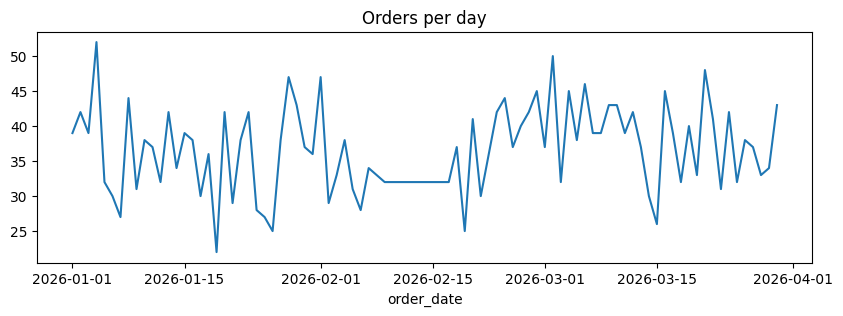

In [17]:
df["order_date"] = df["order_time"].dt.date
df.groupby("order_date").size().plot(figsize=(10, 3), title="Orders per day")

**Model answer:** A clean ~1-week gap in mid-February, most likely a system migration or outage rather than a genuine drop in orders.

### Exercise 11 — Unusual Only in Combination

In [18]:
df["implied_speed_kmh"] = df["distance_km"] / (df["duration_min"] / 60)

df.sort_values("implied_speed_kmh", ascending=False)[
    ["order_id", "zone", "distance_km", "duration_min", "implied_speed_kmh"]
].head(5)

,order_id,zone,distance_km,duration_min,implied_speed_kmh
2279,100350,Heliopolis,11.5,3.000000,230.000000
554,102066,Maadi,11.4,3.000000,228.000000
2676,100528,Zamalek,3.0,3.000000,60.000000
1485,102648,Nasr City,4.9,12.211419,24.075825
1499,102691,El Maadi,7.1,19.346385,22.019618


---
# Section 2 — Logical / Business-Rule Checks

### Exercise 12 — Timestamp Logic

In [19]:
bad_timing = df[df["actual_delivery_time"] < df["order_time"]]
print("Rows where actual_delivery_time is before order_time:", len(bad_timing))

Rows where actual_delivery_time is before order_time: 0


### Exercise 13 — Speed Plausibility

In [20]:
MAX_PLAUSIBLE_KMH = 60
impossible_speed = df[df["implied_speed_kmh"] > MAX_PLAUSIBLE_KMH]
print("Rows implying an impossible delivery speed:", len(impossible_speed))
impossible_speed[["order_id", "distance_km", "duration_min", "implied_speed_kmh"]]

Rows implying an impossible delivery speed: 2


,order_id,distance_km,duration_min,implied_speed_kmh
554,102066,11.4,3.0,228.0
2279,100350,11.5,3.0,230.0


### Exercise 14 — Status Consistency Across Two Columns

In [21]:
cancelled_but_delivered = df[(df["order_status"] == "cancelled") & (df["actual_delivery_time"].notna())]
delivered_but_missing = df[(df["order_status"] == "delivered") & (df["actual_delivery_time"].isna())]

print("Cancelled orders that still show a delivery time:", len(cancelled_but_delivered))
print("Delivered orders missing a delivery time:", len(delivered_but_missing))

Cancelled orders that still show a delivery time: 10
Delivered orders missing a delivery time: 8


**Model answer:** "Cancelled but delivered" could be a refund dispute logged as a cancellation after the fact. "Delivered but missing a timestamp" could be an app crash at drop-off.

### Exercise 15 — Egyptian Mobile Phone Format

In [22]:
phone_pattern = re.compile(r"^01[0125]\d{8}$")

df["valid_phone"] = df["customer_phone"].astype(str).apply(lambda x: bool(phone_pattern.match(x)))

print("Invalid phone numbers:", (~df["valid_phone"]).sum(), f"({(~df['valid_phone']).mean():.1%})")
df.loc[~df["valid_phone"], "customer_phone"].head(10)

Invalid phone numbers: 436 (14.4%)


9        1294154545
12    012-6787-5597
16    011-0913-1685
18      01681992132
22      01668608293
28       1078419211
35    015-5400-2974
37       1048153067
47       1513954572
56          0154646
Name: customer_phone, dtype: str

**Model answer:** At least four patterns: missing leading 0, dash formatting, invalid prefix (013/014/016/019), wrong length.

---
# Section 3 — Discussion: Is This Data Actually Useful for This Problem?

**1. Would you trust this dataset to train an ETA model today, or does it need cleaning first?**

**Model answer:** Not as-is. Must-fix: zone naming (Ex 4/5), the 11 statistical/2 business-rule outliers (Ex 6/13), the 18 status-inconsistent rows (Ex 14) — and now also the statistically-confirmed duration difference in the new zone (Ex 9), which means that zone likely needs to be modeled or handled separately rather than pooled in in as-is. Nice-to-fix: missing courier_id, invalid phones — lower priority for ETA specifically.

**2. What would a model get wrong in Sheikh Zayed Extension, and why won't more of the same data fix it?**

**Model answer:** Ex 9 now gives statistical confirmation, not just a hunch — deliveries there are significantly slower, likely due to different road/courier conditions in a newly launched area. A model trained mostly on established zones would default to their patterns and systematically under-predict ETA there. More of the same kind of data won't fix the root cause (Ex 8's courier/GPS logging gap) — that needs a fix to the logging process itself, or time for adoption to mature.

**3. Name one piece of data that isn't in this dataset that would improve an ETA model.**

**Model answer (any reasonable answer):** restaurant prep time, real-time traffic, weather, or courier profile (vehicle type, tenure).

---
## Wrap-up

Grading note: code exercises are auto-checkable against the exact numbers in each "Expected output" callout in the student version. Section 3 and the interpretation questions should be graded as "engages with the evidence," not matched word-for-word against the model answer.